In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from flatten_wind import *


##### zacetek

In [2]:
def extract_variables(file_path, wind_col_name="wind"):
    df = pd.read_csv(file_path, delimiter=';')
    wind_col_name=df.columns[-1]

    # Apply wind flattening
    if wind_col_name in df.columns:
        wind_df = df[wind_col_name].apply(flatten_wind_blob)
        df = pd.concat([df.drop(columns=[wind_col_name]), wind_df], axis=1)

    # Convert all numeric columns to float
    for col in df.columns:
        try:
            df[col] = df[col].astype(float)
        except:
            continue  # skip non-numeric columns

    return df


In [5]:
def extract_variables2(file_path, wind_col_name="wind"):
    df = pd.read_csv(file_path, delimiter=',')

    # Convert all numeric columns to float
    for col in df.columns:
        try:
            df[col] = df[col].astype(float)
        except:
            continue  # skip non-numeric columns

    return df


In [4]:
folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'
all_stats = []
combined_data = []

for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        try:
            df = extract_variables(os.path.join(folder_path, filename))

            # Only use the first 100 rows or so if needed to standardize
            df_short = df.iloc[:100].copy()
            combined_data.append(df_short)

            # Stats for this file
            stats = df_short.describe().T[["mean", "std", "min", "max"]]
            stats["file"] = filename
            all_stats.append(stats)

        except Exception as e:
            print(f"Failed on {filename}: {e}")


In [6]:
folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds\cleaned2'
all_stats = []
combined_data = []

for filename in os.listdir(folder_path):
    if filename.endswith(".csv"):
        try:
            df = extract_variables2(os.path.join(folder_path, filename))

            # Only use the first 100 rows or so if needed to standardize
            df_short = df.iloc[:100].copy()
            combined_data.append(df_short)

            # Stats for this file
            stats = df_short.describe().T[["mean", "std", "min", "max"]]
            stats["file"] = filename
            all_stats.append(stats)

        except Exception as e:
            print(f"Failed on {filename}: {e}")


In [7]:
# Combine all stats and save to Excel or CSV if needed
stats_df = pd.concat(all_stats)
#stats_df.to_csv("all_flight_stats.csv")

# Combine all data for full dataset analysis
full_df = pd.concat(combined_data, ignore_index=True)


In [8]:
stats_df.head()

,mean,std,min,max,file
Position,47.572600,31.943916,-93.740,98.000,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
Height above ground [m],4.300404,0.707826,2.880,5.370,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
Time,5.987780,1.158196,0.071,7.687,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
X [m],45.892800,29.220743,-81.790,90.590,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
Y [m],-0.712900,0.596577,-1.780,0.010,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...


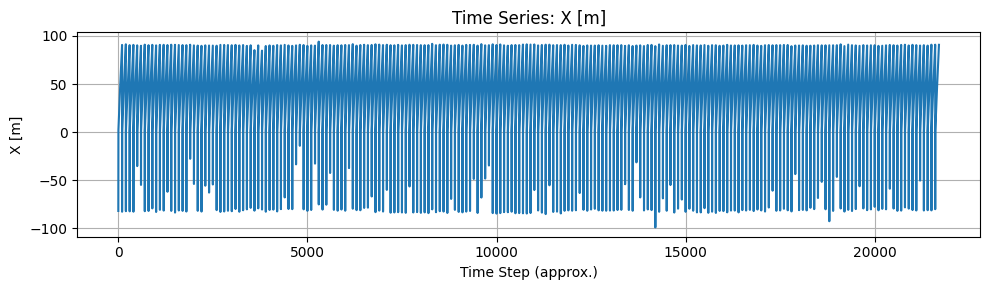

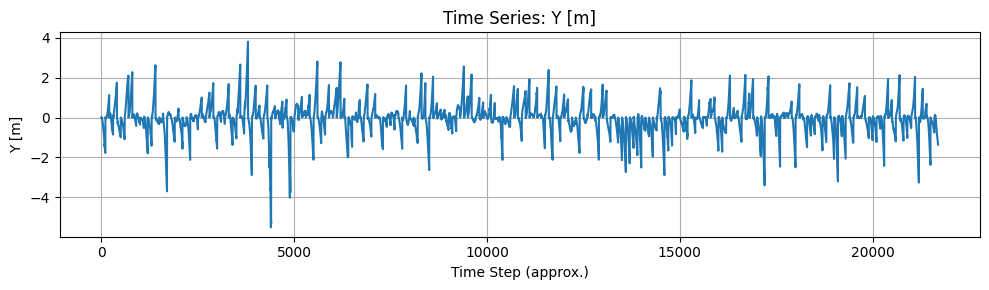

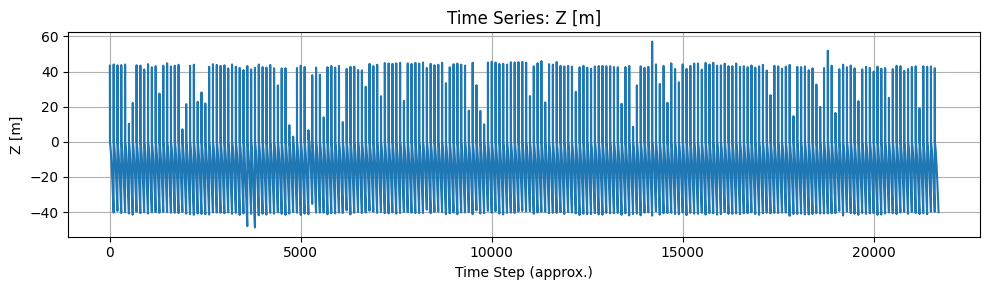

In [54]:
for var in ["X [m]", "Y [m]", "Z [m]"]:
    if var in full_df.columns:
        plt.figure(figsize=(10, 3))
        plt.plot(full_df[var], label=var)
        plt.title(f"Time Series: {var}")
        plt.xlabel("Time Step (approx.)")
        plt.ylabel(var)
        plt.grid(True)
        plt.tight_layout()
        plt.show()


In [55]:
plt.figure(figsize=(12, 10))
corr = full_df[variables].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()



KeyboardInterrupt



<Figure size 1200x1000 with 0 Axes>

##### naprej

In [9]:
import os
import pandas as pd
import numpy as np
import math
from flatten_wind import flatten_wind_blob

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'

all_stats = []

for filename in os.listdir(folder_path):
    if not filename.endswith('.csv'):
        continue

    file_path = os.path.join(folder_path, filename)

    try:
        # Read CSV
        df = pd.read_csv(file_path, delimiter=';')

        # Flatten wind blob
        wind_col = df.columns[-1]
        wind_df = df[wind_col].apply(flatten_wind_blob)
        df_cleaned = pd.concat([df.drop(columns=[wind_col]), wind_df], axis=1)

        # Convert all columns to numeric (if possible)
        for col in df_cleaned.columns:
            df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
        df_cleaned.dropna(axis=1, how='all', inplace=True)

        # Flip Y if needed
        if "Y [m]" in df_cleaned.columns and df_cleaned["Y [m]"].iloc[-1] > 0:
            continue

        # Compute final vector length (based on last row X,Y,Z)
        length = np.nan  # default in case something fails
        if df_cleaned.shape[1] >= 6 and all(col in df_cleaned.columns for col in ['X [m]', 'Y [m]', 'Z [m]']):
            try:
                x = df_cleaned['X [m]'].iloc[-1]
                y = df_cleaned['Y [m]'].iloc[-1]
                z = df_cleaned['Z [m]'].iloc[-1]
                length = math.sqrt(x**2 + y**2 + z**2)
            except Exception:
                pass  # in case values are missing or NaN

        # Compute summary stats
        stats = df_cleaned.agg(['mean', 'std', 'min', 'max']).T.reset_index()
        stats.columns = ['variable', 'mean', 'std', 'min', 'max']
        stats['length'] = length
        stats['filename'] = filename

        all_stats.append(stats)

    except Exception as e:
        print(f"Failed on {filename}: {e}")

# Combine all stats
full_stats_df = pd.concat(all_stats, ignore_index=True)

# Save
full_stats_df.to_csv('stats2.csv', index=False)
print("Saved to stats2.csv")
print("Unique variables:", full_stats_df["variable"].nunique())


Saved to stats2.csv
Unique variables: 75


In [10]:
STATS = full_stats_df
STATS

,variable,mean,std,min,max,length,filename
0,Position,103.056000,61.852201,-93.74,207.50,207.118792,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
1,Height above ground [m],3.636124,1.105913,0.00,5.37,207.118792,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
2,X [m],92.617667,52.281302,-81.79,177.55,207.118792,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
3,Y [m],-2.123952,1.614270,-5.62,0.01,207.118792,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
4,Z [m],-46.087381,33.377492,-106.51,43.40,207.118792,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
...,...,...,...,...,...,...,...
9514,W12_Speed,1.523556,0.119619,1.30,2.00,222.830272,999_999_Jumper_Anon_ANO_1_20240409-103924_C_Of...
9515,W12_Tangent,1.199289,0.251171,0.77,1.74,222.830272,999_999_Jumper_Anon_ANO_1_20240409-103924_C_Of...
9516,W12_Turbulence,0.190444,0.146116,0.00,0.58,222.830272,999_999_Jumper_Anon_ANO_1_20240409-103924_C_Of...
9517,W12_CleanTan,1.199289,0.251171,0.77,1.74,222.830272,999_999_Jumper_Anon_ANO_1_20240409-103924_C_Of...


In [71]:
STATS["variable"].unique()

array(['Position', 'Height above ground [m]', 'X [m]', 'Y [m]', 'Z [m]',
       'Opening Angle [°]', 'Stalling Angle Left [°]',
       'Stalling Angle Right [°]', 'Roll Angle Left [°]',
       'Roll Angle Right [°]', 'Yaw Angle Left [°]',
       'Yaw Angle Right [°]', 'Speed hor. [km/h]', 'Speed vert. [km/h]',
       'Speed resulting [km/h]', 'W1_Speed', 'W1_Tangent',
       'W1_Turbulence', 'W1_CleanTan', 'W1_Cross', 'W2_Speed',
       'W2_Tangent', 'W2_Turbulence', 'W2_CleanTan', 'W2_Cross',
       'W3_Speed', 'W3_Tangent', 'W3_Turbulence', 'W3_CleanTan',
       'W3_Cross', 'W4_Speed', 'W4_Tangent', 'W4_Turbulence',
       'W4_CleanTan', 'W4_Cross', 'W5_Speed', 'W5_Tangent',
       'W5_Turbulence', 'W5_CleanTan', 'W5_Cross', 'W6_Speed',
       'W6_Tangent', 'W6_Turbulence', 'W6_CleanTan', 'W6_Cross',
       'W7_Speed', 'W7_Tangent', 'W7_Turbulence', 'W7_CleanTan',
       'W7_Cross', 'W8_Speed', 'W8_Tangent', 'W8_Turbulence',
       'W8_CleanTan', 'W8_Cross', 'W9_Speed', 'W9_Tangent',

##### dolžina

In [11]:
razpon_dolzine = f"od {STATS["length"].min()} do {STATS["length"].max()}"
razpon_dolzine

'od 117.90960859912987 do 243.79353826547575'

In [12]:
filter = STATS["length"] == STATS["length"].max()
STATS[filter].sort_values(by="mean", ascending=False).drop(columns=["length"])

,variable,mean,std,min,max,filename
5919,Position,121.261057,71.668159,-59.780,244.000,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5933,Speed resulting [km/h],113.867634,10.985671,0.000,123.036,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5921,X [m],107.959837,60.419351,-54.870,209.200,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5931,Speed hor. [km/h],96.233114,6.409463,0.000,99.851,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5927,Roll Angle Left [°],33.953478,13.592162,-2.938,53.844,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
...,...,...,...,...,...,...
5922,Y [m],-3.510691,3.133997,-10.030,0.010,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5930,Yaw Angle Right [°],-14.449890,2.700492,-18.354,0.000,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5928,Roll Angle Right [°],-24.758535,11.979516,-42.764,8.883,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5923,Z [m],-55.888943,38.722018,-124.780,22.250,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...


In [13]:
filter2 = STATS["length"] == STATS["length"].min()
STATS[filter].sort_values(by="mean", ascending=False).drop(columns=["length"])

,variable,mean,std,min,max,filename
5919,Position,121.261057,71.668159,-59.780,244.000,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5933,Speed resulting [km/h],113.867634,10.985671,0.000,123.036,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5921,X [m],107.959837,60.419351,-54.870,209.200,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5931,Speed hor. [km/h],96.233114,6.409463,0.000,99.851,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5927,Roll Angle Left [°],33.953478,13.592162,-2.938,53.844,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
...,...,...,...,...,...,...
5922,Y [m],-3.510691,3.133997,-10.030,0.010,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5930,Yaw Angle Right [°],-14.449890,2.700492,-18.354,0.000,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5928,Roll Angle Right [°],-24.758535,11.979516,-42.764,8.883,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
5923,Z [m],-55.888943,38.722018,-124.780,22.250,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...


##### height above ground

In [14]:
filter = STATS["variable"] == "Height above ground [m]"
STATS[filter].sort_values(by="min", ascending=False).drop(columns=["mean", "std", "variable"])

,min,max,length,filename
2620,2.86,5.59,204.906121,999_999_Jumper_Anon_ANO_1_20240409-103152_C_Of...
4645,0.09,4.78,230.285256,999_999_Jumper_Anon_ANO_1_20240409-103604_C_Of...
1,0.00,5.37,207.118792,999_999_Jumper_Anon_ANO_1_20240409-102625_C_Of...
226,0.00,5.92,195.453608,999_999_Jumper_Anon_ANO_1_20240409-102837_C_Of...
301,0.00,5.05,203.569417,999_999_Jumper_Anon_ANO_1_20240409-102838_C_Of...
...,...,...,...,...
9145,0.00,4.77,230.728091,999_999_Jumper_Anon_ANO_1_20240409-103916_C_Of...
9220,0.00,5.17,218.214657,999_999_Jumper_Anon_ANO_1_20240409-103919_C_Of...
9295,0.00,5.54,231.662573,999_999_Jumper_Anon_ANO_1_20240409-103922_C_Of...
9370,0.00,5.18,224.539780,999_999_Jumper_Anon_ANO_1_20240409-103923_C_Of...


In [15]:
filter = STATS["variable"] == "Height above ground [m]"
STATS[filter].sort_values(by="max", ascending=False).drop(columns=["mean", "std", "variable"])

,min,max,length,filename
2173,0.0,11.86,218.961116,999_999_Jumper_Anon_ANO_1_20240409-103139_C_Of...
8245,0.0,6.59,220.441135,999_999_Jumper_Anon_ANO_1_20240409-103828_C_Of...
5695,0.0,6.34,189.254852,999_999_Jumper_Anon_ANO_1_20240409-103651_C_Of...
9070,0.0,6.11,228.474155,999_999_Jumper_Anon_ANO_1_20240409-103915_C_Of...
1948,0.0,5.96,195.013493,999_999_Jumper_Anon_ANO_1_20240409-103121_C_Of...
...,...,...,...,...
4270,0.0,4.39,216.290391,999_999_Jumper_Anon_ANO_1_20240409-103514_C_Of...
151,0.0,4.30,211.177851,999_999_Jumper_Anon_ANO_1_20240409-102834_C_Of...
8320,0.0,4.29,232.692681,999_999_Jumper_Anon_ANO_1_20240409-103829_C_Of...
3520,0.0,4.13,208.912350,999_999_Jumper_Anon_ANO_1_20240409-103421_C_Of...


In [16]:
filter = (STATS["variable"] == "Height above ground [m]") & (STATS["max"] != 11.86)
STATS[filter].sort_values(by="mean", ascending=False)#.drop(columns=["mean", "std", "variable"])

,variable,mean,std,min,max,length,filename
8245,Height above ground [m],4.631036,1.437965,0.00,6.59,220.441135,999_999_Jumper_Anon_ANO_1_20240409-103828_C_Of...
2695,Height above ground [m],4.619136,1.304693,0.00,5.65,217.917963,999_999_Jumper_Anon_ANO_1_20240409-103358_C_Of...
2620,Height above ground [m],4.449612,0.712735,2.86,5.59,204.906121,999_999_Jumper_Anon_ANO_1_20240409-103152_C_Of...
5695,Height above ground [m],4.348115,1.523305,0.00,6.34,189.254852,999_999_Jumper_Anon_ANO_1_20240409-103651_C_Of...
4045,Height above ground [m],4.292328,1.209539,0.00,5.54,230.371210,999_999_Jumper_Anon_ANO_1_20240409-103506_C_Of...
...,...,...,...,...,...,...,...
1873,Height above ground [m],2.377414,1.314430,0.00,4.46,172.055446,999_999_Jumper_Anon_ANO_1_20240409-103116_C_Of...
5170,Height above ground [m],2.360000,1.560948,0.00,4.78,155.657075,999_999_Jumper_Anon_ANO_1_20240409-103613_C_Of...
8770,Height above ground [m],2.318128,1.134914,0.00,4.53,218.027302,999_999_Jumper_Anon_ANO_1_20240409-103838_C_Of...
8320,Height above ground [m],2.300470,1.025265,0.00,4.29,232.692681,999_999_Jumper_Anon_ANO_1_20240409-103829_C_Of...


##### speed horizontalno

In [72]:
filter = STATS["variable"] == "Speed hor. [km/h]"
STATS[filter].sort_values(by="max", ascending=False).drop(columns=["mean", "std", "variable"])

,min,max,length,filename
2784,0.0,177.806,183.821652,999_999_Jumper_Anon_ANO_1_20240409-103059_C_Of...
2634,0.0,139.943,185.134411,999_999_Jumper_Anon_ANO_1_20240409-103056_C_Of...
3009,0.0,113.590,179.886384,999_999_Jumper_Anon_ANO_1_20240409-103103_C_Of...
8478,0.0,112.451,214.753439,999_999_Jumper_Anon_ANO_1_20240409-103511_C_Of...
7281,0.0,112.110,215.627275,999_999_Jumper_Anon_ANO_1_20240409-103455_C_Of...
...,...,...,...,...
11928,0.0,95.734,168.701385,999_999_Jumper_Anon_ANO_1_20240409-103708_C_Of...
16203,0.0,95.430,222.830272,999_999_Jumper_Anon_ANO_1_20240409-103924_C_Of...
14478,0.0,95.003,199.251436,999_999_Jumper_Anon_ANO_1_20240409-103831_C_Of...
9153,0.0,94.989,153.931436,999_999_Jumper_Anon_ANO_1_20240409-103600_C_Of...


In [78]:
filter = (STATS["variable"] == "Speed hor. [km/h]")
STATS[filter].sort_values(by="mean", ascending=False)#.drop(columns=["mean", "std", "variable"])

,variable,mean,std,min,max,length,filename
3009,Speed hor. [km/h],104.702588,9.566381,0.0,113.590,179.886384,999_999_Jumper_Anon_ANO_1_20240409-103103_C_Of...
2784,Speed hor. [km/h],104.439237,33.388486,0.0,177.806,183.821652,999_999_Jumper_Anon_ANO_1_20240409-103059_C_Of...
11253,Speed hor. [km/h],102.995826,9.246874,0.0,111.516,161.580378,999_999_Jumper_Anon_ANO_1_20240409-103659_C_Of...
8478,Speed hor. [km/h],102.374530,7.834150,0.0,112.451,214.753439,999_999_Jumper_Anon_ANO_1_20240409-103511_C_Of...
8328,Speed hor. [km/h],102.300770,7.910841,0.0,111.536,223.700190,999_999_Jumper_Anon_ANO_1_20240409-103509_C_Of...
...,...,...,...,...,...,...,...
16203,Speed hor. [km/h],88.847560,6.294449,0.0,95.430,222.830272,999_999_Jumper_Anon_ANO_1_20240409-103924_C_Of...
9603,Speed hor. [km/h],88.359684,7.626059,0.0,94.702,149.619497,999_999_Jumper_Anon_ANO_1_20240409-103606_C_Of...
4956,Speed hor. [km/h],87.353485,7.047615,0.0,96.067,194.992174,999_999_Jumper_Anon_ANO_1_20240409-103154_C_Of...
2859,Speed hor. [km/h],86.437858,9.308866,0.0,96.884,117.909609,999_999_Jumper_Anon_ANO_1_20240409-103100_C_Of...


##### optimum

ali so pri daljših poletih izmerjeni koti blizu "optimalnim"?

In [85]:
filter = ((STATS["length"] == STATS["length"].max()) &
    (STATS["variable"].isin([
        "Stalling Angle Left [°]",
        "Stalling Angle Right [°]",
        "Roll Angle Left [°]",
        "Roll Angle Right [°]",
        "Yaw Angle Left [°]",
        "Yaw Angle Right [°]"])))

STATS[filter].sort_values(by="length", ascending=False)


,variable,mean,std,min,max,length,filename
10947,Stalling Angle Left [°],-0.770706,5.683923,-19.372,9.737,243.793538,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
10948,Stalling Angle Right [°],-1.917657,4.011937,-21.955,4.199,243.793538,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
10949,Roll Angle Left [°],33.953478,13.592162,-2.938,53.844,243.793538,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
10950,Roll Angle Right [°],-24.758535,11.979516,-42.764,8.883,243.793538,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
10951,Yaw Angle Left [°],6.333898,4.553981,-0.536,19.121,243.793538,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...
10952,Yaw Angle Right [°],-14.449890,2.700492,-18.354,0.000,243.793538,999_999_Jumper_Anon_ANO_1_20240409-103655_C_Of...


##### size

In [ ]:
#variables = full_stats_df["variable"]
#for var in variables:
#    if var in full_df.columns:
#        plt.figure(figsize=(6, 4))
#        sns.histplot(full_df[var].dropna(), kde=True, bins=30)
#        plt.title(f"Histogram of {var}")
#        plt.xlabel(var)
#        plt.ylabel("Count")
#        plt.tight_layout()
#        plt.show()


In [ ]:
import os
import pandas as pd

folder_path = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\2024_03_Planica_12_winds'

shapes = {}

for filename in os.listdir(folder_path):
    if filename.endswith('.csv'):
        file_path = os.path.join(folder_path, filename)
        try:
            df = pd.read_csv(file_path, delimiter=';')
            shapes[filename] = df.shape
        except Exception as e:
            print(f"Error reading {filename}: {e}")

# Print sorted by row count
for file, shape in sorted(shapes.items(), key=lambda x: x[1][0]):
    print(f"{file}: {shape}")


999_999_Jumper_Anon_ANO_1_20240409-103119_C_OfficialResults.csv: (97, 17)
999_999_Jumper_Anon_ANO_1_20240409-103138_C2_OfficialResults.csv: (103, 17)
999_999_Jumper_Anon_ANO_1_20240409-103100_C_OfficialResults.csv: (120, 17)
999_999_Jumper_Anon_ANO_1_20240409-103619_C_OfficialResults.csv: (128, 17)
999_999_Jumper_Anon_ANO_1_20240409-103616_C_OfficialResults.csv: (133, 17)
999_999_Jumper_Anon_ANO_1_20240409-103053_C_OfficialResults.csv: (141, 17)
999_999_Jumper_Anon_ANO_1_20240409-103606_C_OfficialResults.csv: (152, 17)
999_999_Jumper_Anon_ANO_1_20240409-103600_C_OfficialResults.csv: (156, 17)
999_999_Jumper_Anon_ANO_1_20240409-103122_C_OfficialResults.csv: (161, 17)
999_999_Jumper_Anon_ANO_1_20240409-103613_C_OfficialResults.csv: (161, 17)
999_999_Jumper_Anon_ANO_1_20240409-103656_C_OfficialResults.csv: (161, 17)
999_999_Jumper_Anon_ANO_1_20240409-103711_C_OfficialResults.csv: (163, 17)
999_999_Jumper_Anon_ANO_1_20240409-102845_C_OfficialResults.csv: (166, 17)
999_999_Jumper_Anon_ANO_1